In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
df = pd.read_csv('data/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.shape

(891, 12)

In [11]:
df.count()

PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            714
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          204
Embarked       889
dtype: int64

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [10]:
df_filtrado = df.fillna({'Age':0, 'Cabin':'Desconocida', 'Embarked':'Desconocida'})
df_filtrado.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    str    
 11  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [13]:
df_generos = df.groupby('Sex')
df_generos.describe()

PassengerId                                                             \
             count        mean         std  min     25%    50%     75%    max   
Sex                                                                             
female       314.0  431.028662  256.846324  2.0  231.75  414.5  641.25  889.0   
male         577.0  454.147314  257.486139  1.0  222.00  464.0  680.00  891.0   

       Survived            ... Parch        Fare                              \
          count      mean  ...   75%  max  count       mean        std   min   
Sex                        ...                                                 
female    314.0  0.742038  ...   1.0  6.0  314.0  44.479818  57.997698  6.75   
male      577.0  0.188908  ...   0.0  5.0  577.0  25.523893  43.138263  0.00   

                                          
              25%   50%    75%       max  
Sex                                       
female  12.071875  23.0  55.00  512.3292  
male     7.895800  10.5  26.55  512.3292  

[2 rows x 56 columns]

In [20]:
pasajeros =  df.shape[0]
supervivientes = df[df.Survived == 1].shape[0]
fallecidos = df.query('Survived == 0')
num_survived = supervivientes
print(f'Pasajeros: {pasajeros}')
print(f'Supervivientes: {supervivientes}')
print(f'Fallecidos: {fallecidos.shape[0]}')
print(f'Porcentaje de supervivientes: {num_survived/pasajeros*100:.2f}%')

Pasajeros: 891
Supervivientes: 342
Fallecidos: 549
Porcentaje de supervivientes: 38.38%


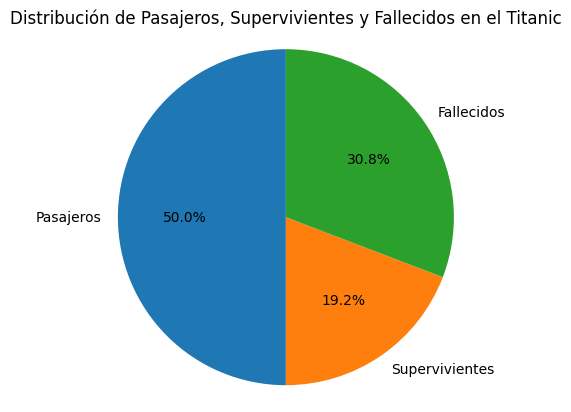

In [21]:
data = {
    'datos': ['Pasajeros', 'Supervivientes', 'Fallecidos'],
    'cantidad': [pasajeros, supervivientes, fallecidos.shape[0]]
}

plt.pie(data['cantidad'], labels=data['datos'], autopct='%1.1f%%', startangle=90)
plt.title('Distribución de Pasajeros, Supervivientes y Fallecidos en el Titanic')
plt.axis('equal')
plt.show()

In [22]:
df_datos = pd.DataFrame(data)
df_datos

,datos,cantidad
0,Pasajeros,891
1,Supervivientes,342
2,Fallecidos,549


<Axes: >

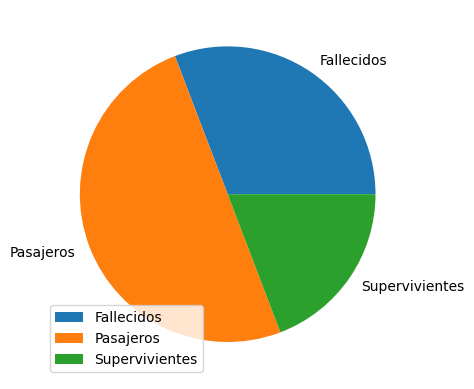

In [26]:
df_datos.groupby('datos').sum().plot(kind='pie', y='cantidad')